# Loading and analyzing the model from Fargo3d

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import cm

In [2]:
alphas=[1e-2,1e-3,1e-4]
alphas_str=["1e-2","1e-3","1e-4"]
paths = []
for alpha in alphas_str:
    path = f"/pfs/10/work/hd_cu284-work/fargo3d/outputs/fargo_a_{alpha}"
    paths.append(path)

In [3]:

max_n =100
rho_cube=[] # first index: which alpha, second index: which snapshot.
for path in paths:
    rho_cube.append([])
    for i in range(max_n+1):
        rho = np.fromfile(f"{path}/gasdens{i}.dat").reshape(128, 384)
        rho_cube[-1].append(rho)

rho_cube=np.array(rho_cube)

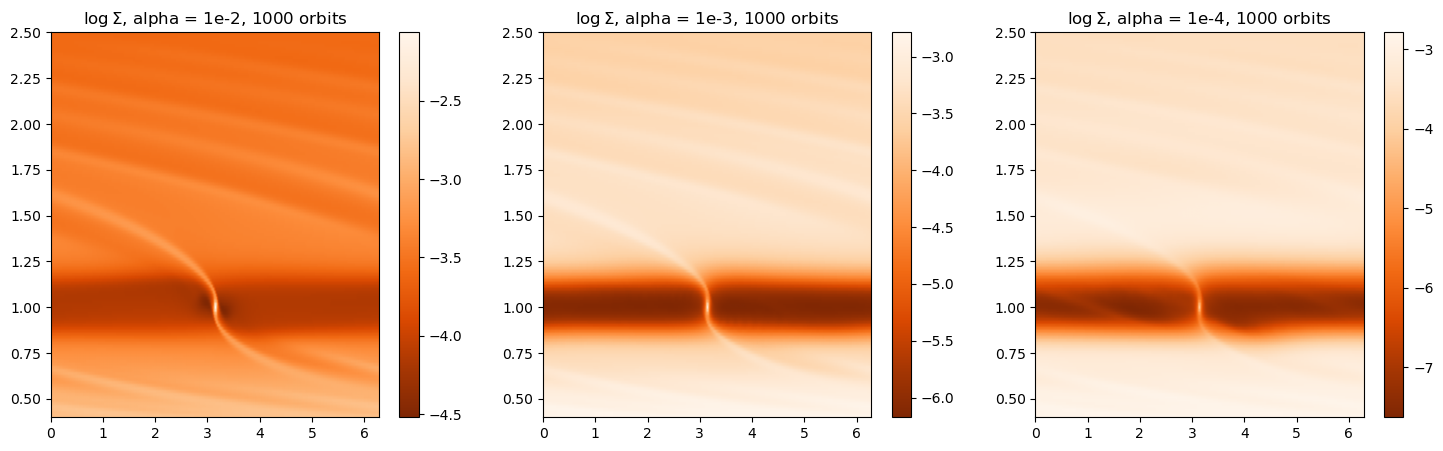

In [4]:
%matplotlib inline

n_frame=max_n
plt.figure(figsize=(18,5))
plt.subplot(1,3,1)
plt.imshow(np.log10(rho_cube[0][n_frame]), origin='lower', cmap=cm.Oranges_r, aspect='auto',extent=[0,2*np.pi,0.4,2.5])
plt.title(f"$\\log \\Sigma$, alpha = {alphas_str[0]}, {(n_frame)*10} orbits")
plt.colorbar()

plt.subplot(1,3,2)
plt.imshow(np.log10(rho_cube[1][n_frame]), origin='lower', cmap=cm.Oranges_r, aspect='auto',extent=[0,2*np.pi,0.4,2.5])
plt.title(f"$\\log \\Sigma$, alpha = {alphas_str[1]}, {(n_frame)*10} orbits")
plt.colorbar()

plt.subplot(1,3,3)
plt.imshow(np.log10(rho_cube[2][n_frame]), origin='lower', cmap=cm.Oranges_r, aspect='auto',extent=[0,2*np.pi,0.4,2.5])
plt.title(f"$\\log \\Sigma$, alpha = {alphas_str[2]}, {(n_frame)*10} orbits")
plt.colorbar()
plt.show()


In [5]:
R_min = 0.4      
R_max = 2.5 
Nr = 128
Nphi = 384

r_list = np.fromfile(f"{path}/domain_y.dat", sep="\n")[3:-4]#R_min * (R_max / R_min)**(np.linspace(0, 1, Nr))
phi = np.linspace(0, 2*np.pi, Nphi)

R, PHI = np.meshgrid(r_list, phi, indexing='ij')

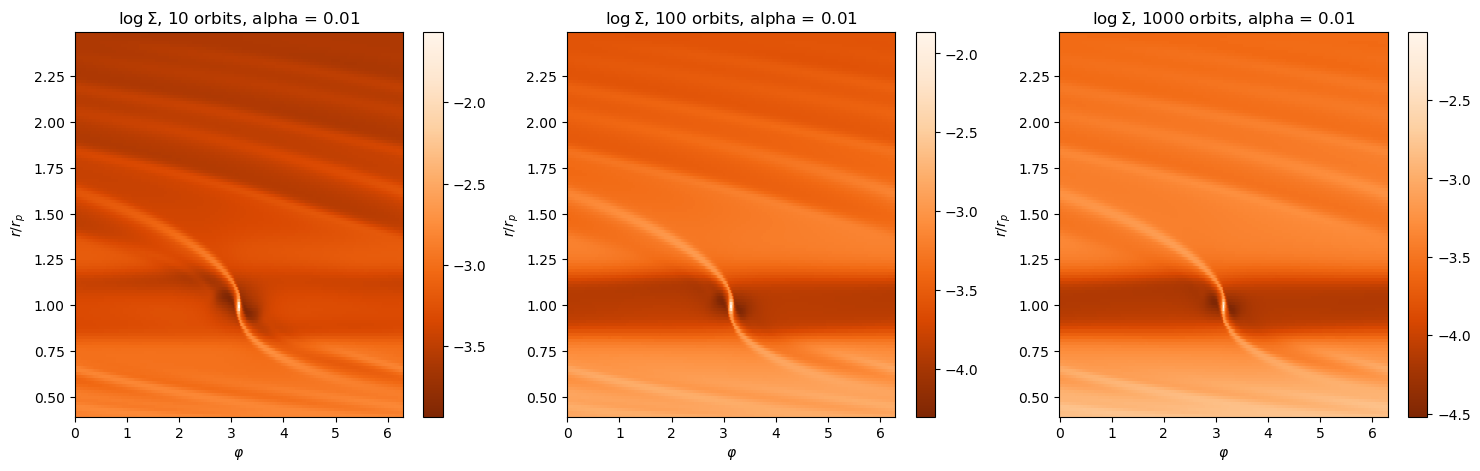

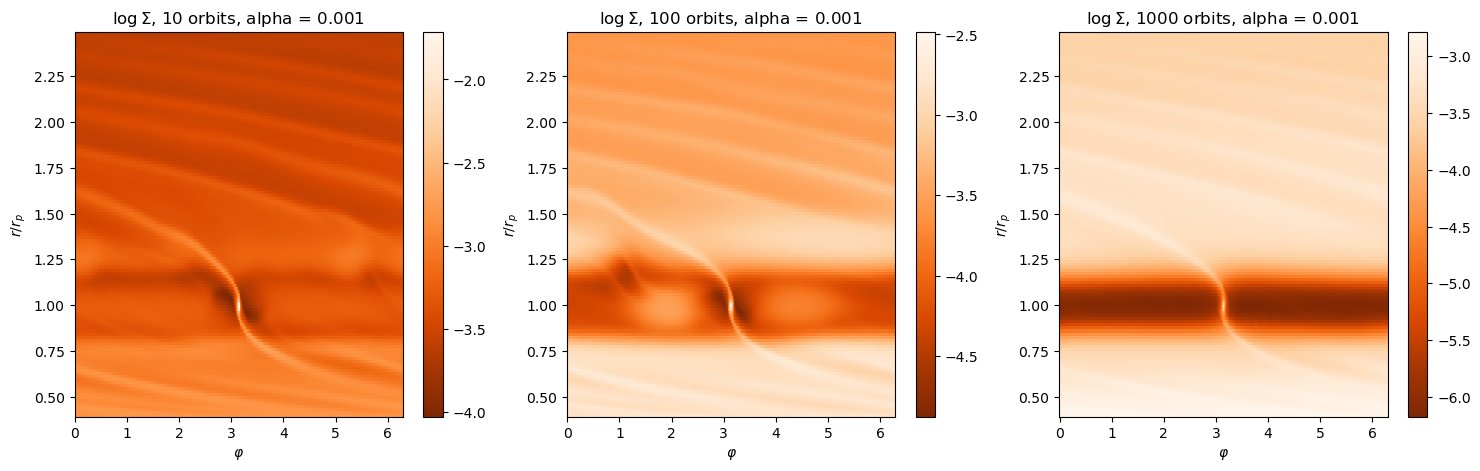

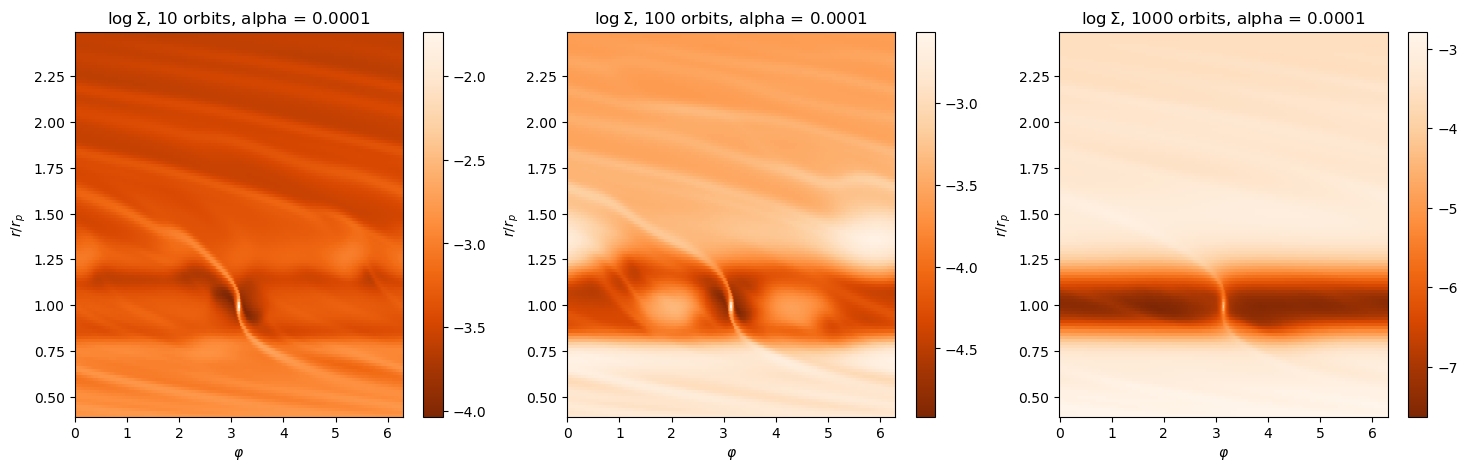

In [6]:
%matplotlib inline

frames = [1,10,100]


for j in range(len(alphas)):
    plt.figure(figsize=(len(frames)*6,5))
    for i,frame in enumerate(frames):
        plt.subplot(1,len(frames),1+i)
        
        plt.pcolormesh(PHI, R, np.log10(rho_cube[j][frame]),cmap=cm.Oranges_r, shading='auto')
        plt.xlabel("$\\varphi$")
        plt.ylabel("$r/r_p$")
        plt.title(f"$\\log \\Sigma$, {frame*10} orbits, alpha = {alphas[j]}")
        plt.colorbar()
    plt.show()


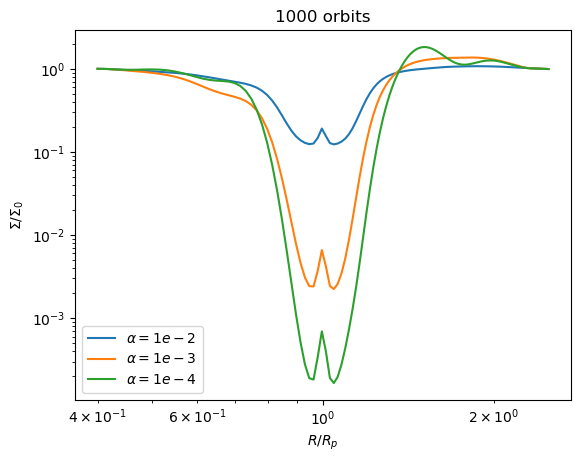

In [7]:
Ymin=0.4		#Inner boundary radius
Ymax=2.5
frame=max_n
rlist = np.linspace(Ymin,Ymax, len(rho_cube[0][0]))
# average surface density at radius r
rho_mean = np.mean(rho_cube, axis=3)
plt.plot(rlist,rho_mean[0][frame]/rho_mean[0][0], label=f"$\\alpha={alphas_str[0]}$")
plt.plot(rlist,rho_mean[1][frame]/rho_mean[1][0], label=f"$\\alpha={alphas_str[1]}$")
plt.plot(rlist,rho_mean[2][frame]/rho_mean[2][0], label=f"$\\alpha={alphas_str[2]}$")
plt.xlabel("$R/R_p$")
plt.ylabel("$\\Sigma/\\Sigma_0$")
#plt.ylim(1e-4,2e-3)
plt.xscale("log")
plt.yscale("log")
plt.title(f"{(frame)*10} orbits")
plt.legend()

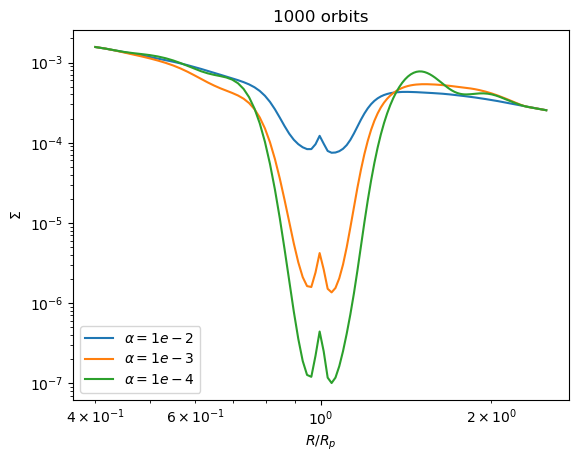

In [8]:
Ymin=0.4		#Inner boundary radius
Ymax=2.5
frame=max_n
rlist = np.linspace(Ymin,Ymax, len(rho_cube[0][0]))
# average surface density at radius r
rho_mean = np.mean(rho_cube, axis=3)
plt.plot(rlist,rho_mean[0][frame], label=f"$\\alpha={alphas_str[0]}$")
plt.plot(rlist,rho_mean[1][frame], label=f"$\\alpha={alphas_str[1]}$")
plt.plot(rlist,rho_mean[2][frame], label=f"$\\alpha={alphas_str[2]}$")
plt.xlabel("$R/R_p$")
plt.ylabel("$\\Sigma$")
#plt.ylim(1e-4,2e-3)
plt.xscale("log")
plt.yscale("log")
plt.title(f"{(frame)*10} orbits")
plt.legend()

In [9]:
#
# Model setup for reading a 2-D (r,phi) model from FARGO3D with dust
# into RADMC-3D.
#
import numpy as np
import matplotlib.pyplot as plt
import readfargo as fg
from makedustopacfortran import create_dustkapscatmat_file
import os
from radmc3dPy.analyze import readOpac
from scipy.optimize import bisect
#
# A simple grid refinement function
#
def grid_refine_inner_edge(x_orig,nlev,nspan):
    x     = x_orig.copy()
    rev   = x[0]>x[1]
    for ilev in range(nlev):
        x_new = 0.5 * ( x[1:nspan+1] + x[:nspan] )
        x_ref = np.hstack((x,x_new))
        x_ref.sort()
        x     = x_ref
        if rev:
            x = x[::-1]
    return x
#
# Some natural constants
#
au  = 1.49598e13     # Astronomical Unit       [cm]
pc  = 3.08572e18     # Parsec                  [cm]
ms  = 1.98892e33     # Solar mass              [g]
ts  = 5.78e3         # Solar temperature       [K]
ls  = 3.8525e33      # Solar luminosity        [erg/s]
rs  = 6.96e10        # Solar radius            [cm]
ss  = 5.6703e-5      # Stefan-Boltzmann const  [erg/cm^2/K^4/s]
kk  = 1.3807e-16     # Bolzmann's constant     [erg/K]
mp  = 1.6726e-24     # Mass of proton          [g]
GG  = 6.67408e-08    # Gravitational constant  [cm^3/g/s^2]
pi  = np.pi          # Pi




Fast (Fortran90) Mie-scattering module could not be imported. Falling back to the slower Python version.


In [10]:
#
# Star parameters
#
"""
This value is taken form the WISPIT paper. 1.1+0.2-0.1 solar masses.
"""
mstar    = 1.1*ms
"""
I don't think we actually *know* the radius of the star in the WISPIT system. This is just a reasonable guess.

"""
rstar    = 1*rs
tstar    = 1e4
pstar    = np.array([0.,0.,0.])

#
# Read a FARGO3D frame
#
# NOTE: Set the dir variable to the simulation you wish to import, and
#       the itime to the time snapshot you are interested in. The FARGO3D
#       simulations are in dimensionless units. By setting r0 in cm (see below)
#       and mstar in gram (see above), the simulation becomes "physical"
#       with units in CGS.
#
path    = path
itime    = 100
r0       = 60*au    # The radius corresponding to '1' in dimensionless units
fargo    = fg.frame(itime,rhodust=True,dir=path)
fargo.convert_to_cgs(mstar,r0)
#fargo.show(q=fargo.sigma_gas_cgs)
#fargo.show(q=fargo.sigma_dust_cgs[0])

fargo.sigma_gas_cgs *=100

In [11]:
#
# Make the RADMC-3D radial and phi grids
#

"""
I'm not 100% this is the correct way to do it for a logarithmic grid. But I assume the shift this
can cause is pretty small.

Nah, I think it's fine because the readfargo.py code has this line:

        self.r   = (r[3:-4]*r[4:-3])**0.5

That should work for log grids. On the other hand, phi gets

        self.phi = 0.5 * ( phi[:-1] + phi[1:] )

Which is correct for linear grids.
"""
ri       = 0.5*(fargo.r_cgs[1:]+fargo.r_cgs[:-1])
ri       = np.hstack([2*ri[0]-ri[1],ri,2*ri[-1]-ri[-2]])
rc       = 0.5 * ( ri[:-1] + ri[1:] )#np.sqrt(ri[:-1] * ri[1:])
nr       = len(rc)   # Recompute nr, because of refinement at inner edge
r        = rc        # The radial grid of the analytic disk model (below)
phii     = 0.5*(fargo.phi[1:]+fargo.phi[:-1])+np.pi
phii     = np.hstack([2*phii[0]-phii[1],phii,2*phii[-1]-phii[-2]])
phic     = 0.5 * ( phii[:-1] + phii[1:] )
nphi     = len(phic)
r_2d,phi_2d = np.meshgrid(rc,phic,indexing='ij')



first number should be smaller than 1, second number should be greater than 1 : 0.900353250203862 1.1464550248342673
r0 should be reasonably in the middle: 54.02119501223172 60.0 68.78730149005604
phi0 should be reasonably in the middle: 2.9043369583968137 3.141592653589793 3.3952108105202186


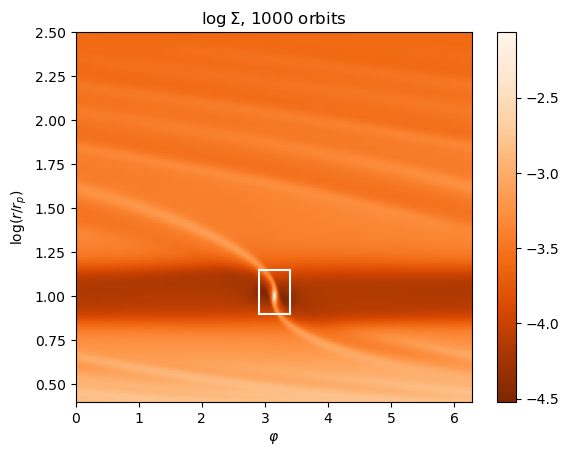

The piece we cut out:


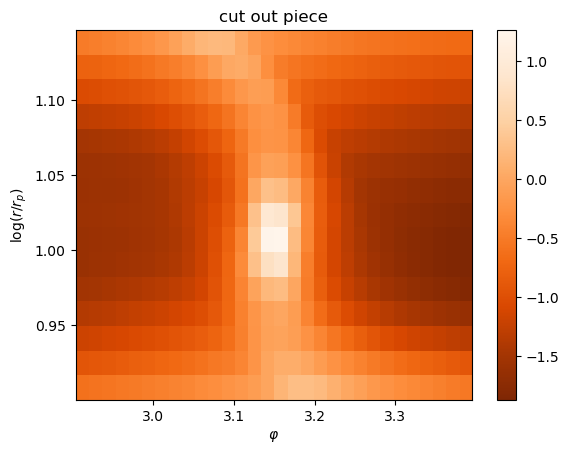

Text(0, 0.5, '$\\Sigma$ [g/cm²]')

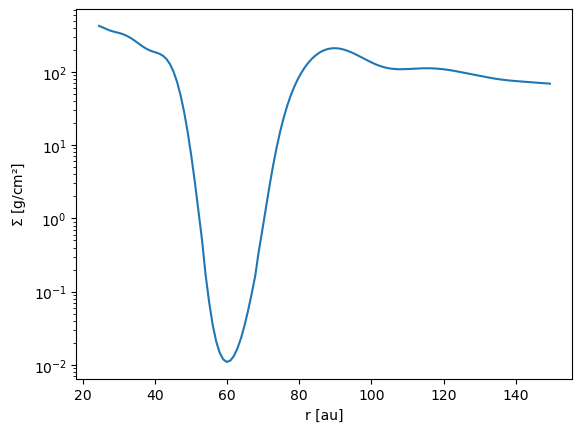

In [12]:
## removing the annoying bump around the planet.

# choose the starting index (radius) of the planet region
i_start = 30
# end index (in r) of the planet region
i_end = 45

# starting index (angle)
j_start = int(len(phic)/2-15)
# stopping index (angle)
j_end = int(len(phic)/2+15)

cut_indices=[i_start, i_end, j_start, j_end]

print("first number should be smaller than 1, second number should be greater than 1 :",rc[i_start]/r0, rc[i_end]/r0)
print("r0 should be reasonably in the middle:",rc[i_start]/au, r0/au, rc[i_end]/au)

print("phi0 should be reasonably in the middle:",phic[j_start], np.pi, phic[j_end])

plt.imshow(np.log10(rho_cube[0][frame]), origin='lower', cmap=cm.Oranges_r, aspect='auto',extent=[0,2*np.pi,0.4,2.5])
plt.title(f"$\\log \\Sigma$, {frame*10} orbits")
plt.plot([phic[j_start],phic[j_start]],[(rc[i_start]/r0), (rc[i_end]/r0)], c="w")
plt.plot([phic[j_end],phic[j_end]],[(rc[i_start]/r0), (rc[i_end]/r0)], c="w")
plt.plot([phic[j_start],phic[j_end]],[(rc[i_start]/r0), (rc[i_start]/r0)], c="w")
plt.plot([phic[j_start],phic[j_end]],[(rc[i_end]/r0), (rc[i_end]/r0)], c="w")

plt.colorbar()
plt.xlabel("$\\varphi$")
plt.ylabel("$\\log(r/r_p)$")
plt.show()

print("The piece we cut out:")

plt.imshow(np.log10(fargo.sigma_gas_cgs[i_start:i_end,j_start:j_end]), origin='lower', 
           cmap=cm.Oranges_r, aspect='auto',extent=[phic[j_start],phic[j_end],rc[i_start]/r0,rc[i_end]/r0])
plt.colorbar()
plt.xlabel("$\\varphi$")
plt.ylabel("$\\log(r/r_p)$")
plt.title("cut out piece")
plt.show()

# middle:
rho_mean_mid = np.mean(np.concatenate((fargo.sigma_gas_cgs[i_start:i_end,:j_start], fargo.sigma_gas_cgs[i_start:i_end,j_end:]), axis=1), axis=1)
rho_mean = np.append(np.mean(fargo.sigma_gas_cgs[:i_start], axis=1),rho_mean_mid)
rho_mean = np.append(rho_mean,np.mean(fargo.sigma_gas_cgs[i_end:], axis=1))

plt.plot(rc/au, rho_mean)
plt.yscale("log")
plt.xlabel("r [au]")
plt.ylabel("$\\Sigma$ [g/cm²]")

# check all the slicing works as intended
#plt.show()
#plt.imshow(fargo.sigma_gas_cgs[:i_start])
#plt.imshow(fargo.sigma_gas_cgs[i_end:])
#plt.imshow(np.concatenate((fargo.sigma_gas_cgs[i_start:i_end,:j_start], fargo.sigma_gas_cgs[i_start:i_end,j_end:]), axis=1))

# Turning this into a setup for radmc3d

You can also find this in `altered_setup.py`

In [13]:
import os
# so it can find Radmc3D
os.environ["PATH"] += ":/home/hd/hd_hd/hd_cu284/bin"
# so it can find other libraries Radmc3D depends on that I cannot access from inside the singularity container.
# DO NOT TOUCH!!!!
os.environ["LD_LIBRARY_PATH"] = "/home/hd/hd_hd/hd_cu284/libs:" + os.environ.get("LD_LIBRARY_PATH", "")
# Change path to dir that contains all the radmc3d-relevant files, like dust_density.inp etc.
os.chdir("/home/hd/hd_hd/hd_cu284/jupyter notebooks/different_viscs_run_ppdisk_fargo3d")

In [14]:
import sys
# python won't find the helper files otherwise.
sys.path.append("/home/hd/hd_hd/hd_cu284/jupyter notebooks/different_viscs_run_ppdisk_fargo3d/")

import os

# Add the library path for libgfortran.so.5
os.environ['LD_LIBRARY_PATH'] = '/usr/lib64:' + os.environ.get('LD_LIBRARY_PATH', '')


In [15]:

#from altered_setup_azimuhtal_avg import main
#sigma_dust_2d = main(paths[0], cut_indices)

/pfs/10/work/hd_cu284-work/fargo3d/outputs/fargo_a_1e-4
1 dust species detected!
Please check that the RADMC-3D setup is roughly consistent with the FARGO3D setup:
  AspectRatio in RADMC-3D model at R0  = 0.08076526195932285
  FlaringIndex in RADMC-3D model at R0 = 0.24869935813845404
If these values are vastly different from those in the FARGO3D .par file,
you should either modify the parameters in the RADMC-3D model, or the parameters
in the FARGO3D model, to make them both mutually self-consistent.
Reading dustkapscatmat_1.00e-01.inp


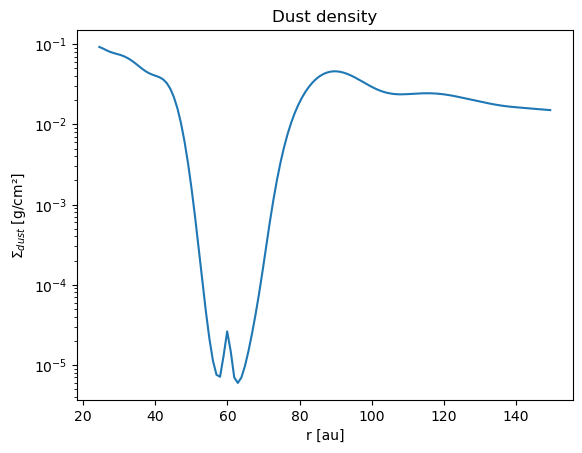

In [16]:
from altered_setup4 import main
sigma_dust_2d = main(paths[2])

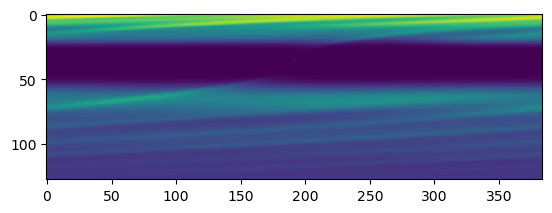

In [66]:
plt.imshow(sigma_dust_2d[0])

## Investigating opacity $\tau$

We make a rough estimate for particles of size 0.1µm (the ones we used here) with data from the dustkapscatmat_1.00e-01.inp file. (We interpolate to get the correct values for the wavelengths of the K band and H band).
The leftmost value is $\lambda$ in µm, followed by $\kappa_{abs}$ and $\kappa_{scat}$ and $g = <\cos \theta>$.
We use $\kappa = \kappa_{abs}+\kappa_{scat}$

In [67]:
path = "/home/hd/hd_hd/hd_cu284/jupyter notebooks/different_viscs_run_ppdisk_fargo3d"
## caution: I figured out skiprows and maxrows by trial-and-error. 
dustkapscatmat= np.loadtxt(f"{path}/dustkapscatmat_1.00e-01.inp", comments="#", skiprows=17,max_rows=150)

wavelengths = np.array(dustkapscatmat[:,0])
kappa_abs = np.array(dustkapscatmat[:,1])
kappa_scat = np.array(dustkapscatmat[:,2])
kappa_tot = kappa_abs+kappa_scat

lambda_K = 2.2 #µm
lambda_H = 1.65 #µm

kappa_tot_K, kappa_tot_H = np.interp([lambda_K, lambda_H], wavelengths, kappa_tot) # cm²/g



Minimum optical depth (K band): 0.00195365627911747
Minimum optical depth (H band): 0.005639947584651898


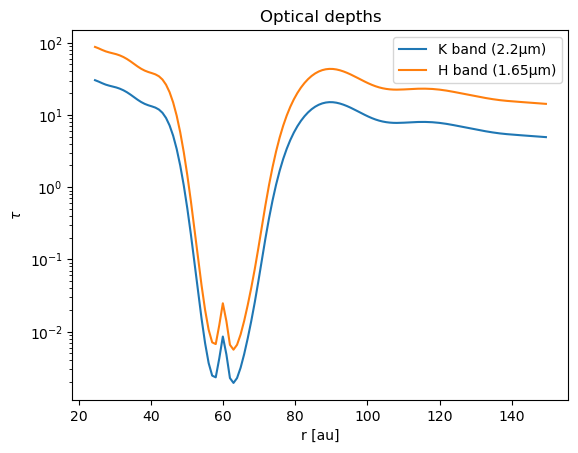

In [70]:

rho_mean = np.mean(sigma_dust_2d[0], axis=1)
tau_K = kappa_tot_K * rho_mean
tau_H = kappa_tot_H * rho_mean

plt.plot(rc/au, tau_K, label="K band (2.2µm)")
plt.plot(rc/au, tau_H, label="H band (1.65µm)")
plt.yscale("log")
plt.xlabel("r [au]")
plt.ylabel("$\\tau$")
plt.legend()
plt.title("Optical depths")

print("Minimum optical depth (K band):", min(tau_K))
print("Minimum optical depth (H band):", min(tau_H))


Weird stuff is happening with the optical depth. Why is it so different for the different alphas???

### Investigating differences in optical depth

/pfs/10/work/hd_cu284-work/fargo3d/outputs/fargo_a_1e-2
1 dust species detected!
Please check that the RADMC-3D setup is roughly consistent with the FARGO3D setup:
  AspectRatio in RADMC-3D model at R0  = 0.08076526195932285
  FlaringIndex in RADMC-3D model at R0 = 0.24869935813845404
If these values are vastly different from those in the FARGO3D .par file,
you should either modify the parameters in the RADMC-3D model, or the parameters
in the FARGO3D model, to make them both mutually self-consistent.
Reading dustkapscatmat_1.00e-01.inp
/pfs/10/work/hd_cu284-work/fargo3d/outputs/fargo_a_1e-3
1 dust species detected!
Please check that the RADMC-3D setup is roughly consistent with the FARGO3D setup:
  AspectRatio in RADMC-3D model at R0  = 0.08076526195932285
  FlaringIndex in RADMC-3D model at R0 = 0.24869935813845404
If these values are vastly different from those in the FARGO3D .par file,
you should either modify the parameters in the RADMC-3D model, or the parameters
in the FARGO3D m

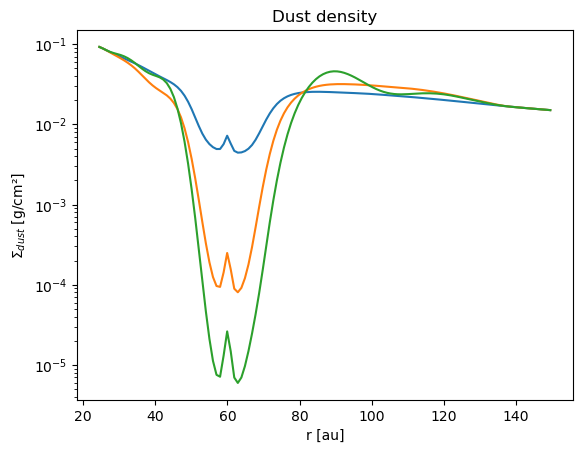

In [19]:
from altered_setup4 import main

sigmas = []
for i in range(len(alphas)):
    sigma_dust_2d = main(paths[i])[0]
    sigmas.append(sigma_dust_2d)



Text(0.5, 1.0, 'optical depth in K band')

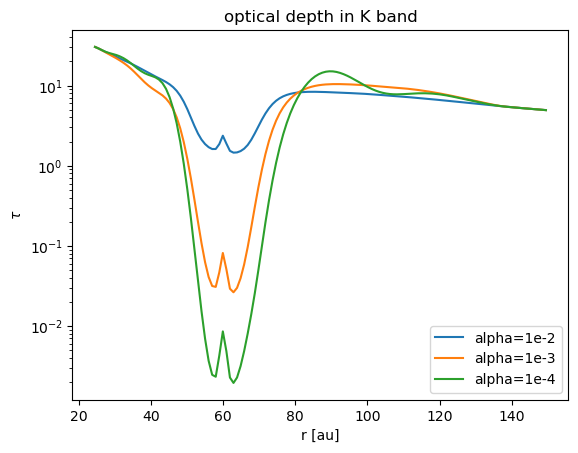

In [74]:
rho_mean = np.mean(sigmas, axis=2)
tau = kappa_tot_K * rho_mean
for i in range(len(alphas)):
    plt.plot(rc/au, tau[i], label=f"alpha={alphas_str[i]}")
plt.yscale("log")
plt.xlabel("r [au]")
plt.ylabel("$\\tau$")
plt.legend()
plt.title("optical depth in K band")


Text(0.5, 1.0, 'Densities')

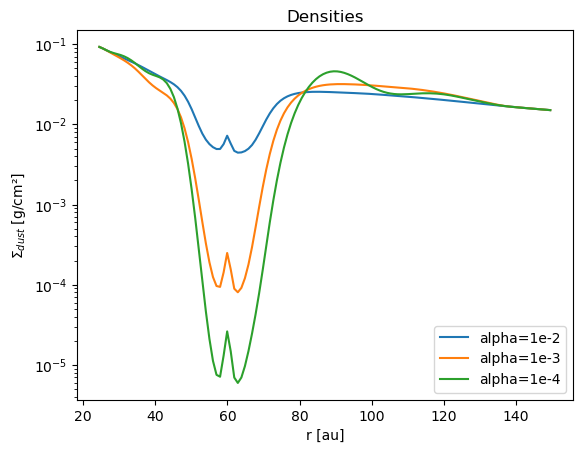

In [73]:
kappa_tot = kappa_abs+kappa_scat
rho_mean = np.mean(sigmas, axis=2)
for i in range(len(alphas)):
    plt.plot(rc/au, rho_mean[i], label=f"alpha={alphas_str[i]}")
plt.yscale("log")
plt.xlabel("r [au]")
plt.ylabel("$\\Sigma_{dust}$ [g/cm²]")
plt.legend()
plt.title("Densities")


Text(0.5, 1.0, 'Densities')

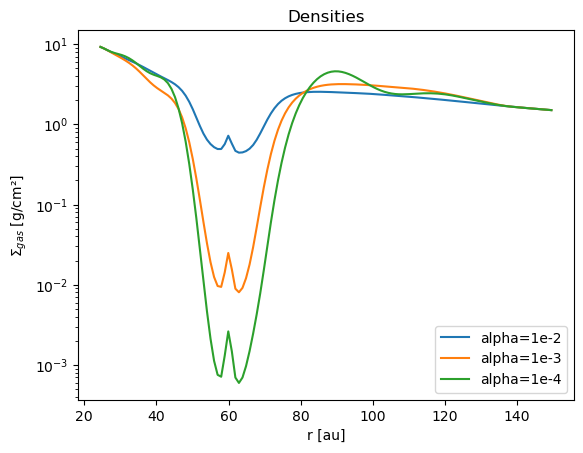

In [75]:
kappa_tot = kappa_abs+kappa_scat
rho_mean = np.mean(sigmas, axis=2)
for i in range(len(alphas)):
    plt.plot(rc/au, rho_mean[i]*100, label=f"alpha={alphas_str[i]}")
plt.yscale("log")
plt.xlabel("r [au]")
plt.ylabel("$\\Sigma_{gas}$ [g/cm²]")
plt.legend()
plt.title("Densities")
